# Electro–thermal coupling: compact canonical ensemble

This notebook is a **compact open-source canonical adaptation of the Multiphysics Bench electro–thermal model**, not a bitwise or FEM-equivalent reproduction. It follows the TE-polarized scalar model

$$
\nabla^2 E_z+k_0^2\mu_r\left(\varepsilon_r-j\frac{\sigma(T)}{\omega\varepsilon_0}\right)E_z=0,
\qquad
\nabla\cdot(\kappa\nabla T)+\frac12\sigma(T)|E_z|^2=0.
$$

The silicon ellipse couples the fields in both directions: the complex electric field creates Joule heating, while temperature changes silicon conductivity. We assume the $e^{+j\omega t}$ harmonic convention. The incident field is represented explicitly and the scattered field is damped by a polynomial complex-coordinate stretch in a 10 mm absorbing layer; this finite-difference absorbing layer is the principal departure from the upstream COMSOL/PML/FEM model. The heat equation uses a variable-conductivity second-order flux stencil and convective Robin boundaries.

The physical output square is 0.128 m × 0.128 m. Normal mode generates 16 deterministic Sobol samples on a boundary-inclusive 128 × 128 grid. `PHYCOFLOW_VIZ_SMOKE=1` selects two samples on a smaller grid. Raw fields remain in physical units; normalization is a separate ensemble-wide view. Sparse masks are Boolean and never confuse missing values with physical zero.

Adapted from *Multiphysics Bench: Benchmarking and Investigating Scientific Machine Learning for Multiphysics PDEs* (arXiv:2505.17575v1) and the MIT-licensed `xie-lab-ml/multiphysics-bench` code at commit `1195b44915712929d605ee5076a831c7124ead93`, especially `TE_heat.m` and the released TE sparse-observation script.

The six-panel dashboard argues one conclusion: each realization preserves the coupled electric/thermal structure while exposing exactly where sparse reconstruction is constrained. Level-set geometry is a topology-oriented preview, not a persistent-homology implementation.


In [ ]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.stats import qmc
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

try:
    from IPython.display import HTML, display
except ImportError:  # Allows smoke validation as a plain Python script.
    HTML = None
    display = None

case_name = "electro_thermal"
version_label = "compact-multiphysics-bench-v1"
upstream_commit = "1195b44915712929d605ee5076a831c7124ead93"
electro_thermal_seed = 23
smoke_mode = os.environ.get("PHYCOFLOW_VIZ_SMOKE", "0") == "1"
save_compact_dataset = False

n = 32 if smoke_mode else 128
sample_count = 2 if smoke_mode else 16
physical_length = 0.128
absorbing_thickness = 0.010
ambient_temperature = 293.15
convective_coefficient = 15.0
frequency = 4.0e9
incident_amplitude = 3.0e5
incident_angle = np.pi / 3.0
epsilon_0 = 8.8541878128e-12
mu_r = 1.0
permittivity_silicon = 11.7
permittivity_alumina = 1.0
conductivity_alumina = 1.0e-7
thermal_conductivity_silicon = 70.0
coupling_tolerance = 1.0e-6
maximum_coupling_iterations = 30
under_relaxation = 0.65
pml_strength = 4.0
pml_power = 3

channel_names = ("E_z_real", "E_z_imag", "temperature")
channel_units = ("V/m", "V/m", "K")
parameter_names = ("a", "b", "phi", "Sigma_Si", "kappa_alumina")
protocol_names = ("official_independent_500", "shared_500")

# Boundary-inclusive physical grid. The absorbing grid uses the same spacing;
# its discrete thickness is the nearest integer number of grid intervals.
x = np.linspace(-physical_length / 2.0, physical_length / 2.0, n, dtype=np.float64)
y = np.linspace(-physical_length / 2.0, physical_length / 2.0, n, dtype=np.float64)
xx, yy = np.meshgrid(x, y, indexing="xy")
dx = x[1] - x[0]
dy = y[1] - y[0]
pml_cells = max(2, int(round(absorbing_thickness / dx)))
full_n = n + 2 * pml_cells
x_full = (np.arange(full_n) - (full_n - 1) / 2.0) * dx
y_full = (np.arange(full_n) - (full_n - 1) / 2.0) * dy
xx_full, yy_full = np.meshgrid(x_full, y_full, indexing="xy")
physical_slice = np.s_[pml_cells : pml_cells + n, pml_cells : pml_cells + n]

omega = 2.0 * np.pi * frequency
speed_of_light = 299792458.0
k0 = omega / speed_of_light

# Scrambled Sobol points are deterministic for the fixed seed. Powers of two
# avoid balance warnings and give reproducible coverage of all five parameters.
sobol = qmc.Sobol(d=5, scramble=True, seed=electro_thermal_seed)
unit_parameters = sobol.random_base2(m=int(np.log2(sample_count)))
sample_parameters = qmc.scale(
    unit_parameters,
    [0.020, 0.010, 0.0, 1.0e11, 10.0],
    [0.030, 0.020, 2.0 * np.pi, 3.0e11, 20.0],
).astype(np.float64)


def rotated_ellipse_mask(a, b, phi):
    """Evaluate the upstream-style rotated material ellipse on output points."""
    cosine, sine = np.cos(phi), np.sin(phi)
    rotated_x = cosine * xx + sine * yy
    rotated_y = -sine * xx + cosine * yy
    return (rotated_x / a) ** 2 + (rotated_y / b) ** 2 <= 1.0


ellipse_masks = np.asarray(
    [rotated_ellipse_mask(a, b, phi) for a, b, phi, _, _ in sample_parameters],
    dtype=bool,
)


def silicon_conductivity(temperature, sigma_prefactor):
    temperature = np.asarray(temperature, dtype=np.float64)
    if np.any(temperature <= 0.0):
        raise FloatingPointError("nonpositive absolute temperature in conductivity law")
    return 1.602 * sigma_prefactor * np.exp(
        -1.12 / (8.6173e-5 * temperature)
    )


# The legacy upstream material channel mixed unrelated physical quantities.
# It is retained only for compatibility; canonical conditioning is the Boolean
# ellipse mask plus the five scalar parameters above.
legacy_material_map = np.asarray(
    [
        np.where(mask, parameters[3], parameters[4])
        for mask, parameters in zip(ellipse_masks, sample_parameters)
    ],
    dtype=np.float64,
)



## Coupled sparse solvers

For $e^{+j\omega t}$, the coordinate stretch uses $s=1-j\alpha d^3$, where $d$ is normalized depth into the absorbing shell. The total field is $E_z=E_{\rm inc}+E_{\rm sc}$; only the scattered field is set to zero at the outer edge, after attenuation through the absorbing layer. This avoids the unacceptable zero-total-field box condition.

The thermal matrix discretizes $-\nabla\cdot(\kappa\nabla T)=q_J$ with harmonic face conductivity. Boundary rows impose outward conductive heat flux equal to $h(T-T_\infty)$. Each sample is solved by under-relaxed Picard iteration until relative infinity-norm changes in both temperature and conductivity fall below $10^{-6}$.


In [ ]:
def coordinate_stretch(coordinates):
    depth = np.maximum(np.abs(coordinates) - physical_length / 2.0, 0.0)
    normalized_depth = depth / absorbing_thickness
    return 1.0 - 1j * pml_strength * normalized_depth**pml_power


def build_pml_laplacian():
    sx = coordinate_stretch(x_full)
    sy = coordinate_stretch(y_full)
    sx_face = 0.5 * (sx[:-1] + sx[1:])
    sy_face = 0.5 * (sy[:-1] + sy[1:])
    rows, columns, values = [], [], []
    boundary = np.zeros((full_n, full_n), dtype=bool)
    boundary[[0, -1], :] = True
    boundary[:, [0, -1]] = True
    for row in range(full_n):
        for column in range(full_n):
            index = row * full_n + column
            if boundary[row, column]:
                rows.append(index); columns.append(index); values.append(1.0 + 0.0j)
                continue
            west = 1.0 / (sx[column] * sx_face[column - 1] * dx**2)
            east = 1.0 / (sx[column] * sx_face[column] * dx**2)
            south = 1.0 / (sy[row] * sy_face[row - 1] * dy**2)
            north = 1.0 / (sy[row] * sy_face[row] * dy**2)
            rows.extend((index, index, index, index, index))
            columns.extend((index, index - 1, index + 1, index - full_n, index + full_n))
            values.extend((-(west + east + south + north), west, east, south, north))
    matrix = sp.csr_matrix((values, (rows, columns)), shape=(full_n**2, full_n**2))
    return matrix, boundary


pml_laplacian, electric_outer_boundary = build_pml_laplacian()
incident_field = incident_amplitude * np.exp(
    1j
    * k0
    * (-xx_full * np.cos(incident_angle) - yy_full * np.sin(incident_angle))
)


def solve_electric_field(ellipse_mask, temperature, sigma_prefactor):
    epsilon_relative = np.full((full_n, full_n), permittivity_alumina, dtype=np.float64)
    sigma = np.full((full_n, full_n), conductivity_alumina, dtype=np.float64)
    epsilon_crop = np.where(ellipse_mask, permittivity_silicon, permittivity_alumina)
    sigma_crop = np.where(
        ellipse_mask,
        silicon_conductivity(temperature, sigma_prefactor),
        conductivity_alumina,
    )
    epsilon_relative[physical_slice] = epsilon_crop
    sigma[physical_slice] = sigma_crop
    complex_permittivity = epsilon_relative - 1j * sigma / (omega * epsilon_0)
    potential = k0**2 * mu_r * complex_permittivity
    potential[electric_outer_boundary] = 0.0
    operator = pml_laplacian + sp.diags(potential.ravel(), format="csr")
    right_hand_side = -(operator @ incident_field.ravel())
    right_hand_side[electric_outer_boundary.ravel()] = 0.0
    scattered = spla.spsolve(operator.tocsc(), right_hand_side).reshape(full_n, full_n)
    total = incident_field + scattered
    if not np.isfinite(total).all():
        raise FloatingPointError("non-finite Helmholtz solution")
    return total[physical_slice], sigma_crop


def harmonic_mean(first, second):
    return 2.0 * first * second / (first + second + 1.0e-300)


def build_heat_operator(thermal_conductivity):
    rows, columns, values = [], [], []
    robin_rhs = np.zeros(n * n, dtype=np.float64)
    boundary_mask = np.zeros((n, n), dtype=bool)
    boundary_mask[[0, -1], :] = True
    boundary_mask[:, [0, -1]] = True
    for row in range(n):
        for column in range(n):
            index = row * n + column
            if boundary_mask[row, column]:
                diagonal = 0.0
                boundary_count = 0
                if column == 0:
                    coefficient = thermal_conductivity[row, column] / dx
                    diagonal += coefficient; boundary_count += 1
                    rows.append(index); columns.append(index + 1); values.append(-coefficient)
                if column == n - 1:
                    coefficient = thermal_conductivity[row, column] / dx
                    diagonal += coefficient; boundary_count += 1
                    rows.append(index); columns.append(index - 1); values.append(-coefficient)
                if row == 0:
                    coefficient = thermal_conductivity[row, column] / dy
                    diagonal += coefficient; boundary_count += 1
                    rows.append(index); columns.append(index + n); values.append(-coefficient)
                if row == n - 1:
                    coefficient = thermal_conductivity[row, column] / dy
                    diagonal += coefficient; boundary_count += 1
                    rows.append(index); columns.append(index - n); values.append(-coefficient)
                diagonal += boundary_count * convective_coefficient
                robin_rhs[index] = boundary_count * convective_coefficient * ambient_temperature
                rows.append(index); columns.append(index); values.append(diagonal)
                continue
            west = harmonic_mean(thermal_conductivity[row, column], thermal_conductivity[row, column - 1]) / dx**2
            east = harmonic_mean(thermal_conductivity[row, column], thermal_conductivity[row, column + 1]) / dx**2
            south = harmonic_mean(thermal_conductivity[row, column], thermal_conductivity[row - 1, column]) / dy**2
            north = harmonic_mean(thermal_conductivity[row, column], thermal_conductivity[row + 1, column]) / dy**2
            rows.extend((index, index, index, index, index))
            columns.extend((index, index - 1, index + 1, index - n, index + n))
            values.extend((west + east + south + north, -west, -east, -south, -north))
    matrix = sp.csr_matrix((values, (rows, columns)), shape=(n * n, n * n))
    return matrix, robin_rhs, boundary_mask


def robin_residual(temperature, thermal_conductivity):
    pieces_flux = (
        thermal_conductivity[:, 0] * (temperature[:, 1] - temperature[:, 0]) / dx,
        thermal_conductivity[:, -1] * (temperature[:, -2] - temperature[:, -1]) / dx,
        thermal_conductivity[0, :] * (temperature[1, :] - temperature[0, :]) / dy,
        thermal_conductivity[-1, :] * (temperature[-2, :] - temperature[-1, :]) / dy,
    )
    pieces_robin = (
        convective_coefficient * (temperature[:, 0] - ambient_temperature),
        convective_coefficient * (temperature[:, -1] - ambient_temperature),
        convective_coefficient * (temperature[0, :] - ambient_temperature),
        convective_coefficient * (temperature[-1, :] - ambient_temperature),
    )
    flux = np.concatenate(pieces_flux)
    robin = np.concatenate(pieces_robin)
    return np.linalg.norm(flux - robin) / (
        np.linalg.norm(flux) + np.linalg.norm(robin) + 1.0e-30
    )


def coupled_sample(parameters, ellipse_mask):
    _, _, _, sigma_prefactor, kappa_alumina = parameters
    thermal_conductivity = np.where(
        ellipse_mask, thermal_conductivity_silicon, kappa_alumina
    )
    heat_operator, robin_rhs, heat_boundary = build_heat_operator(thermal_conductivity)
    heat_solve = spla.factorized(heat_operator.tocsc())
    temperature = np.full((n, n), ambient_temperature, dtype=np.float64)
    sigma_previous = np.where(
        ellipse_mask,
        silicon_conductivity(temperature, sigma_prefactor),
        conductivity_alumina,
    )
    final_temperature_update = np.inf
    final_conductivity_update = np.inf
    for iteration in range(1, maximum_coupling_iterations + 1):
        electric_field, _ = solve_electric_field(
            ellipse_mask, temperature, sigma_prefactor
        )
        sigma_current = np.where(
            ellipse_mask,
            silicon_conductivity(temperature, sigma_prefactor),
            conductivity_alumina,
        )
        joule_heating = 0.5 * sigma_current * np.abs(electric_field) ** 2
        right_hand_side = joule_heating.ravel().copy()
        right_hand_side[heat_boundary.ravel()] = robin_rhs[heat_boundary.ravel()]
        candidate = heat_solve(right_hand_side).reshape(n, n)
        relaxed = temperature + under_relaxation * (candidate - temperature)
        sigma_next = np.where(
            ellipse_mask,
            silicon_conductivity(relaxed, sigma_prefactor),
            conductivity_alumina,
        )
        final_temperature_update = np.max(np.abs(relaxed - temperature)) / (
            np.max(np.abs(relaxed)) + 1.0e-30
        )
        final_conductivity_update = np.max(np.abs(sigma_next - sigma_previous)) / (
            np.max(np.abs(sigma_next)) + 1.0e-30
        )
        temperature = relaxed
        sigma_previous = sigma_next
        if max(final_temperature_update, final_conductivity_update) < coupling_tolerance:
            break
    else:
        raise RuntimeError("electro-thermal Picard coupling failed after 30 iterations")
    electric_field, sigma_final = solve_electric_field(
        ellipse_mask, temperature, sigma_prefactor
    )
    joule_heating = 0.5 * sigma_final * np.abs(electric_field) ** 2
    if np.min(temperature) < ambient_temperature - 1.0e-7:
        raise RuntimeError("temperature dropped below ambient beyond solver tolerance")
    return {
        "field": np.stack((electric_field.real, electric_field.imag, temperature)),
        "electric": electric_field,
        "temperature": temperature,
        "sigma": sigma_final,
        "joule_heating": joule_heating,
        "thermal_conductivity": thermal_conductivity,
        "heat_operator": heat_operator,
        "robin_rhs": robin_rhs,
        "heat_boundary": heat_boundary,
        "iterations": iteration,
        "temperature_update": final_temperature_update,
        "conductivity_update": final_conductivity_update,
    }


sample_solutions = [
    coupled_sample(parameters, mask)
    for parameters, mask in zip(sample_parameters, ellipse_masks)
]
fields = np.asarray([solution["field"] for solution in sample_solutions], dtype=np.float64)
# fields: [sample, channel=(Re Ez, Im Ez, T), y, x]



## Sparse observations, common normalization, and reusable metrics

The official protocol co-locates real and imaginary electric measurements (seed 1) and uses a separate temperature mask (seed 0). The required shared-mask ablation uses seed 0 everywhere. Each channel has exactly 500 unique spatial sensors. Offsets and robust scales are estimated once from the first half of this deterministic ensemble; no sample normalizes itself.


In [ ]:
def sensor_indices(seed):
    return np.random.default_rng(seed).choice(n * n, 500, replace=False)


electric_indices = sensor_indices(1)
temperature_indices = sensor_indices(0)
shared_indices = sensor_indices(0)
sensor_indices_official = np.stack(
    (electric_indices, electric_indices, temperature_indices)
)
sensor_indices_shared = np.stack((shared_indices, shared_indices, shared_indices))


def indices_to_masks(indices):
    masks = np.zeros((len(channel_names), n * n), dtype=bool)
    for channel, channel_indices in enumerate(indices):
        masks[channel, channel_indices] = True
    return masks.reshape(len(channel_names), n, n)


sensor_masks = np.stack(
    (indices_to_masks(sensor_indices_official), indices_to_masks(sensor_indices_shared))
)
sensor_coordinates = np.empty((2, len(channel_names), 500, 2), dtype=np.float64)
for protocol in range(2):
    source_indices = sensor_indices_official if protocol == 0 else sensor_indices_shared
    for channel in range(len(channel_names)):
        rows, columns = np.unravel_index(source_indices[channel], (n, n))
        sensor_coordinates[protocol, channel] = np.column_stack((x[columns], y[rows]))

training_fields = fields[: sample_count // 2]
channel_offset = np.asarray(
    [training_fields[:, 0].mean(), training_fields[:, 1].mean(), ambient_temperature],
    dtype=np.float64,
)
channel_scale = np.asarray(
    [
        max(
            np.quantile(
                np.abs(training_fields[:, channel] - channel_offset[channel]), 0.99
            ),
            1.0e-12,
        )
        for channel in range(len(channel_names))
    ],
    dtype=np.float64,
)
normalized = (fields - channel_offset[None, :, None, None]) / channel_scale[
    None, :, None, None
]
observations = np.where(
    sensor_masks[:, None, :, :, :], normalized[None, :, :, :, :], np.nan
)


def reconstruction_metrics(prediction, target, mask):
    """Per-channel relative L2/NRMSE on unobserved points plus sensor consistency."""
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    mask = np.asarray(mask, dtype=bool)
    relative_l2, normalized_rmse, observed_consistency = [], [], []
    for channel in range(target.shape[0]):
        unseen = ~mask[channel]
        error = prediction[channel, unseen] - target[channel, unseen]
        relative_l2.append(
            np.linalg.norm(error) / (np.linalg.norm(target[channel, unseen]) + 1.0e-30)
        )
        normalized_rmse.append(
            np.sqrt(np.mean(error**2)) / (np.std(target[channel, unseen]) + 1.0e-30)
        )
        observed_consistency.append(
            np.sqrt(np.mean((prediction[channel, mask[channel]] - target[channel, mask[channel]]) ** 2))
        )
    return {
        "relative_l2_unobserved": np.asarray(relative_l2),
        "normalized_rmse_unobserved": np.asarray(normalized_rmse),
        "observed_consistency_rmse": np.asarray(observed_consistency),
    }


def joint_sliced_wasserstein_inputs(field):
    """Return one row per spatial point and one column per normalized channel."""
    return np.moveaxis(np.asarray(field), 0, -1).reshape(-1, len(channel_names))


def radial_spectral_error_inputs(prediction, target):
    """Return shell-averaged, Hann-windowed powers as [shell, channel] arrays."""
    window = np.outer(np.hanning(n), np.hanning(n))
    modes = np.fft.fftfreq(n) * n
    mx, my = np.meshgrid(modes, modes, indexing="xy")
    shell = np.sqrt(mx**2 + my**2).astype(int)
    outputs = []
    for data in (prediction, target):
        spectra = []
        for channel in range(len(channel_names)):
            centered = (data[channel] - data[channel].mean()) * window
            power = np.abs(np.fft.fft2(centered)) ** 2 / centered.size**2
            total = np.bincount(shell.ravel(), weights=power.ravel())
            count = np.maximum(np.bincount(shell.ravel()), 1)
            spectra.append(total / count)
        outputs.append(np.stack(spectra, axis=-1))
    return tuple(outputs)



## Numerical and data diagnostics

Interior residuals exclude two physical boundary cells and are normalized by the sum of constituent-term norms. Robin mismatch is evaluated separately. The diagnostics dictionary also enforces deterministic parameter coverage and the exact sparse sensor budget.


In [ ]:
def physical_laplacian(field):
    return (
        (field[2:-2, 3:-1] - 2.0 * field[2:-2, 2:-2] + field[2:-2, 1:-3]) / dx**2
        + (field[3:-1, 2:-2] - 2.0 * field[2:-2, 2:-2] + field[1:-3, 2:-2]) / dy**2
    )


helmholtz_residuals = []
heat_residuals = []
robin_residuals = []
for parameters, mask, solution in zip(sample_parameters, ellipse_masks, sample_solutions):
    electric = solution["electric"]
    sigma = solution["sigma"]
    epsilon_relative = np.where(mask, permittivity_silicon, permittivity_alumina)
    laplace_term = physical_laplacian(electric)
    potential_term = (
        k0**2
        * mu_r
        * (epsilon_relative[2:-2, 2:-2] - 1j * sigma[2:-2, 2:-2] / (omega * epsilon_0))
        * electric[2:-2, 2:-2]
    )
    helmholtz_residuals.append(
        np.linalg.norm(laplace_term + potential_term)
        / (np.linalg.norm(laplace_term) + np.linalg.norm(potential_term) + 1.0e-30)
    )
    heat_rhs = solution["joule_heating"].ravel().copy()
    heat_rhs[solution["heat_boundary"].ravel()] = solution["robin_rhs"][solution["heat_boundary"].ravel()]
    heat_vector_residual = (
        solution["heat_operator"] @ solution["temperature"].ravel() - heat_rhs
    ).reshape(n, n)[2:-2, 2:-2]
    conduction_scale = (
        solution["heat_operator"] @ solution["temperature"].ravel()
    ).reshape(n, n)[2:-2, 2:-2]
    source_scale = solution["joule_heating"][2:-2, 2:-2]
    heat_residuals.append(
        np.linalg.norm(heat_vector_residual)
        / (np.linalg.norm(conduction_scale) + np.linalg.norm(source_scale) + 1.0e-30)
    )
    robin_residuals.append(
        robin_residual(solution["temperature"], solution["thermal_conductivity"])
    )

deterministic_parameter_hash = hashlib.sha256(
    np.ascontiguousarray(sample_parameters).tobytes()
).hexdigest()
diagnostics = {
    "finite": bool(np.isfinite(fields).all()),
    "maximum_coupling_iterations": int(max(s["iterations"] for s in sample_solutions)),
    "maximum_relative_temperature_update": float(max(s["temperature_update"] for s in sample_solutions)),
    "maximum_relative_conductivity_update": float(max(s["conductivity_update"] for s in sample_solutions)),
    "relative_helmholtz_residual": float(max(helmholtz_residuals)),
    "relative_heat_residual": float(max(heat_residuals)),
    "relative_robin_boundary_residual": float(max(robin_residuals)),
    "minimum_temperature": float(fields[:, 2].min()),
    "maximum_temperature": float(fields[:, 2].max()),
    "minimum_abs_electric_field": float(min(np.abs(s["electric"]).min() for s in sample_solutions)),
    "maximum_abs_electric_field": float(max(np.abs(s["electric"]).max() for s in sample_solutions)),
    "sensor_count_per_channel": tuple(int(mask.sum()) for mask in sensor_masks[0]),
    "deterministic_parameter_hash": deterministic_parameter_hash,
}

assert fields.shape == (sample_count, 3, n, n)
assert sample_parameters.shape == (sample_count, 5)
assert ellipse_masks.shape == (sample_count, n, n)
assert diagnostics["finite"]
assert diagnostics["maximum_coupling_iterations"] <= maximum_coupling_iterations
assert diagnostics["sensor_count_per_channel"] == (500, 500, 500)
assert np.array_equal(sensor_indices_official[0], sensor_indices_official[1])
assert diagnostics["minimum_temperature"] >= ambient_temperature - 1.0e-7
diagnostics



## Optional compact export

Nothing is saved by default. Enabling `save_compact_dataset` writes one compressed float32 NPZ plus provenance JSON and refuses any archive above 64 MiB. Normalized values are not duplicated.


In [ ]:
export_metadata = None
if save_compact_dataset:
    output_npz = Path("electro_thermal_compact.npz")
    np.savez_compressed(
        output_npz,
        fields=fields.astype(np.float32),
        x=x,
        y=y,
        sample_parameters=sample_parameters,
        ellipse_masks=ellipse_masks,
        sensor_indices_official=sensor_indices_official,
        sensor_indices_shared=sensor_indices_shared,
        channel_offset=channel_offset,
        channel_scale=channel_scale,
    )
    if output_npz.stat().st_size > 64 * 2**20:
        raise RuntimeError("compact electro-thermal archive exceeds 64 MiB")
    archive_hash = hashlib.sha256(output_npz.read_bytes()).hexdigest()
    export_metadata = {
        "case_name": case_name,
        "version_label": version_label,
        "channel_names": channel_names,
        "channel_units": channel_units,
        "parameter_names": parameter_names,
        "seed": electro_thermal_seed,
        "upstream_commit": upstream_commit,
        "source_urls": [
            "https://arxiv.org/abs/2505.17575",
            "https://github.com/xie-lab-ml/multiphysics-bench",
        ],
        "grid_shape": [n, n],
        "solver_tolerance": coupling_tolerance,
        "sha256": archive_hash,
    }
    Path("electro_thermal_compact.json").write_text(
        json.dumps(export_metadata, indent=2), encoding="utf-8"
    )



## Six-panel sparse-reconstruction audit

The dashboard slides across ensemble members. Electric panels share their co-located official sensors; temperature uses its independent sensor set. Spectra are shell averages of Hann-windowed fields, which is appropriate labeling for this non-periodic grid.


In [ ]:
def shell_spectrum(field):
    window = np.outer(np.hanning(n), np.hanning(n))
    centered = (field - field.mean()) * window
    power = np.abs(np.fft.fft2(centered)) ** 2 / centered.size**2
    modes = np.fft.fftfreq(n) * n
    mx, my = np.meshgrid(modes, modes, indexing="xy")
    shell = np.sqrt(mx**2 + my**2).astype(int)
    total = np.bincount(shell.ravel(), weights=power.ravel())
    count = np.maximum(np.bincount(shell.ravel()), 1)
    return np.arange(total.size), total / count


def draw_sample(sample_index, axes):
    for axis in axes.ravel():
        axis.clear()
    electric_real, electric_imag, temperature = fields[sample_index]
    electric_mask = sensor_masks[0, 0]
    temperature_mask = sensor_masks[0, 2]
    extent = (x[0], x[-1], y[0], y[-1])
    for axis, field, title, mask, cmap in (
        (axes[0, 0], electric_real, r"$\mathrm{Re}(E_z)$", electric_mask, "RdBu_r"),
        (axes[0, 1], electric_imag, r"$\mathrm{Im}(E_z)$", electric_mask, "RdBu_r"),
        (axes[0, 2], temperature, "Temperature", temperature_mask, "inferno"),
    ):
        axis.imshow(field, origin="lower", extent=extent, cmap=cmap, aspect="equal")
        rows, columns = np.nonzero(mask)
        axis.scatter(x[columns], y[rows], s=2, c="white", alpha=0.45, linewidths=0)
        axis.set(xlabel="x [m]", ylabel="y [m]", title=title)
    stride = max(1, n * n // 2500)
    cloud = axes[1, 0].scatter(
        electric_real.ravel()[::stride],
        electric_imag.ravel()[::stride],
        c=temperature.ravel()[::stride],
        s=6,
        cmap="inferno",
        alpha=0.45,
    )
    axes[1, 0].set(
        xlabel=r"$\mathrm{Re}(E_z)$ [V/m]",
        ylabel=r"$\mathrm{Im}(E_z)$ [V/m]",
        title="Joint field cloud; color=T",
    )
    radius_e, spectrum_e = shell_spectrum(np.abs(electric_real + 1j * electric_imag))
    radius_t, spectrum_t = shell_spectrum(temperature)
    axes[1, 1].semilogy(radius_e[1:], spectrum_e[1:] + 1.0e-30, label=r"$|E_z|$")
    axes[1, 1].semilogy(radius_t[1:], spectrum_t[1:] + 1.0e-30, label="T")
    axes[1, 1].set(xlabel="radial grid-frequency shell", ylabel="windowed shell mean power", title="Electric/thermal spectra")
    axes[1, 1].legend()
    mask = ellipse_masks[sample_index]
    axes[1, 2].contour(xx, yy, mask.astype(float), levels=[0.5], colors="black", linewidths=1.2)
    axes[1, 2].contour(xx, yy, temperature, levels=4, colors="tab:red", linewidths=0.7)
    axes[1, 2].contour(xx, yy, np.abs(electric_real + 1j * electric_imag), levels=4, colors="tab:blue", linewidths=0.7)
    axes[1, 2].set(xlabel="x [m]", ylabel="y [m]", aspect="equal", title="Ellipse, T and |Ez| level sets")
    parameters = sample_parameters[sample_index]
    axes[1, 2].text(
        0.02,
        0.02,
        f"a={parameters[0]*1e3:.1f} mm\nb={parameters[1]*1e3:.1f} mm",
        transform=axes[1, 2].transAxes,
        fontsize=7,
        va="bottom",
    )
    return [cloud]


dashboard = None
if not smoke_mode and HTML is not None:
    figure, dashboard_axes = plt.subplots(
        2, 3, figsize=(12, 7), dpi=72, constrained_layout=True
    )
    animation = FuncAnimation(
        figure,
        lambda index: draw_sample(index, dashboard_axes),
        frames=np.arange(sample_count),
        interval=300,
        repeat=True,
    )
    plt.close(figure)
    dashboard = HTML(animation.to_jshtml(default_mode="once"))
    display(dashboard)


## Validated script-pipeline demo

The embedded panel below was generated by the standalone pipeline, not by the in-notebook solver: one 48 × 48 steady Sobol realization was written to checksummed raw NPZ/JSON, converted to unified HDF5, and rendered from the processed tensor dataset. It verifies complex-field scattering, ellipse geometry, Joule heating, and thermal response together.

```bash
conda run -n phycoflow_env python datagen/5_electro_thermal/generate.py --backend numpy --device cpu --resolution 48 --num-trajectories 1 --dataset-id electro_thermal_demo
conda run -n phycoflow_env python datagen/5_electro_thermal/postprocessing.py --raw-dir datagen/data/raw/electro_thermal/electro_thermal_demo --output datagen/data/processed/electro_thermal_demo.h5 --split-ratios 1 0 0
conda run -n phycoflow_env python datagen/5_electro_thermal/visualize.py --input datagen/data/processed/electro_thermal_demo.h5 --trajectory 0 --time-index 0 --output datagen/data/demos/electro_thermal_demo_qa.png
```


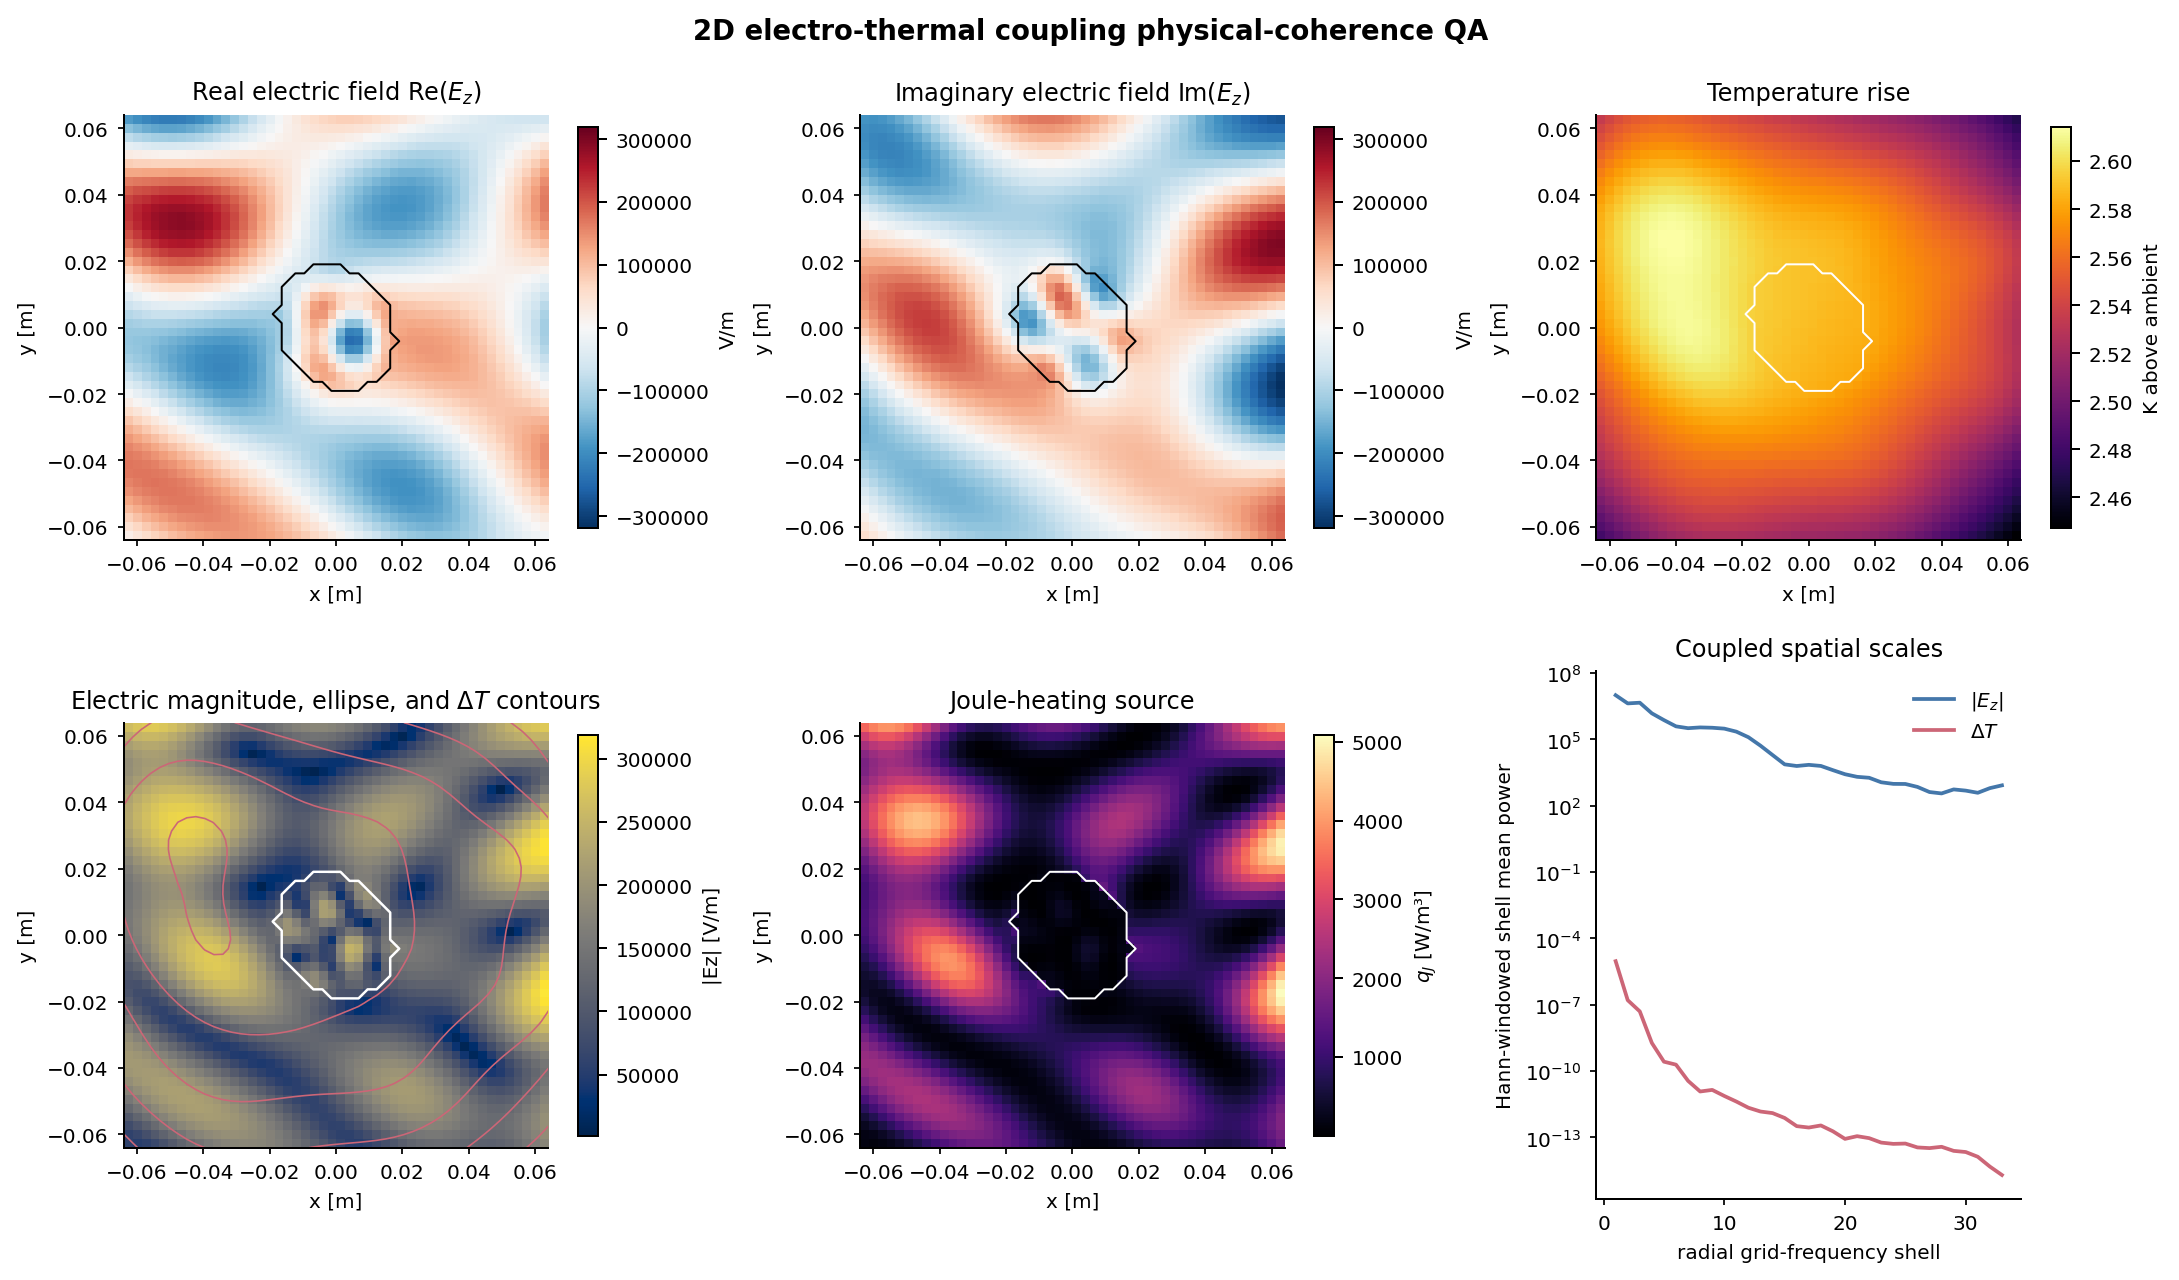

In [1]:
from IPython.display import Image as NotebookImage, display as notebook_display

demo_candidates = (
    Path("datagen/data/demos/electro_thermal_demo_qa.png"),
    Path("../data/demos/electro_thermal_demo_qa.png"),
)
demo_figure_path = next((path for path in demo_candidates if path.is_file()), None)
if demo_figure_path is None:
    print("Run the three validated pipeline commands above to recreate the demo figure.")
else:
    notebook_display(NotebookImage(filename=str(demo_figure_path)))
